# Active Region Detection using Aditya-L1 SUIT Data

Internship Project – Part 1

Objective:
To detect solar active regions from Aditya-L1 SUIT ultraviolet images using image processing techniques and validate the results using NOAA Solar Region Summary data.

In [1]:
import sunpy.map
import numpy as np
import matplotlib.pyplot as plt

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

print("Libraries loaded successfully")

c:\Users\Trijal\OneDrive\Desktop\ADITYA_L1_ PROJECT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully


In [2]:
import sunpy.map

file_path = r"../DATA/raw/SUT_T24_0025_000016_Lev1.0_2024-01-07T00.04.50.320_0973NB04.fits"

smap = sunpy.map.Map(file_path)

data = smap.data.astype(float)

print("Image Shape:", data.shape)

Image Shape: (704, 704)


## Image Preprocessing and Normalization

The raw FITS image was loaded using SunPy and converted into a numerical array. The image intensities were normalized to a range of 0 to 1 to improve visualization and prepare the data for active region detection.

Min: 0.0
Max: 1.0


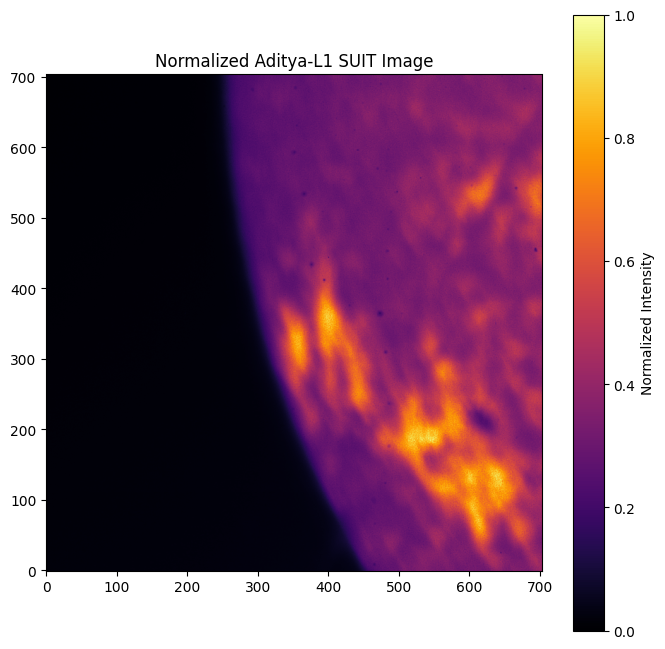

In [3]:
import numpy as np
import matplotlib.pyplot as plt

normalized = (data - np.min(data)) / (np.max(data) - np.min(data))

print("Min:", np.min(normalized))
print("Max:", np.max(normalized))

plt.figure(figsize=(8,8))
plt.imshow(normalized, origin="lower", cmap="inferno")
plt.colorbar(label="Normalized Intensity")
plt.title("Normalized Aditya-L1 SUIT Image")
plt.show()

## Active Region Detection

Active regions are bright ultraviolet structures present on the solar disk. A fixed intensity threshold of 0.7 was applied to isolate bright regions. Small noisy detections were removed using morphological filtering.

C:\Users\Trijal\AppData\Local\Temp\ipykernel_11704\2136667184.py:5: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, 100)


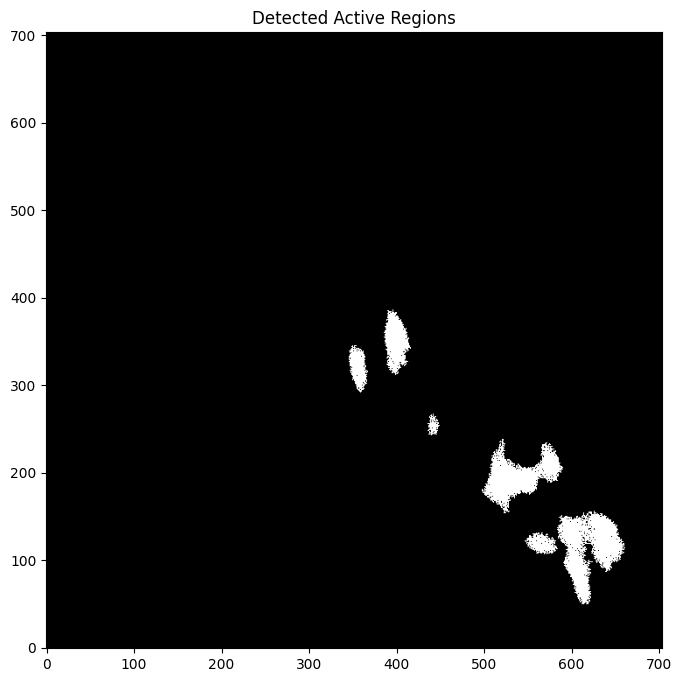

In [4]:
from skimage.morphology import remove_small_objects

mask = normalized > 0.7

mask = remove_small_objects(mask, 100)

plt.figure(figsize=(8,8))
plt.imshow(mask, origin="lower", cmap="gray")
plt.title("Detected Active Regions")
plt.show()

## Region Labeling and Active Region Identification

Connected bright regions were identified using connected-component labeling. Bounding boxes were drawn around each detected active region to visualize their locations on the solar disk.

Number of detected regions: 6


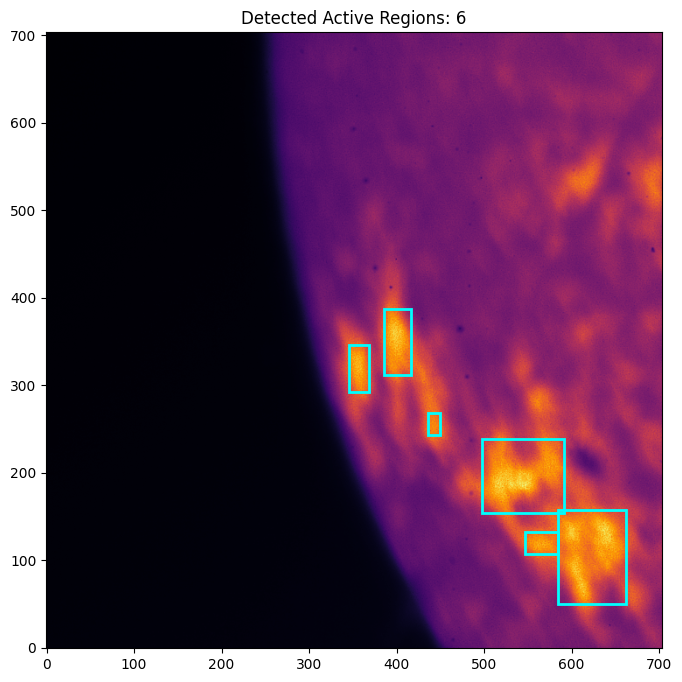

In [5]:
from skimage.measure import label, regionprops

labels = label(mask)

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(normalized, origin="lower", cmap="inferno")

count = 0

for region in regionprops(labels):

    if region.area < 100:
        continue

    minr, minc, maxr, maxc = region.bbox

    rect = plt.Rectangle(
        (minc, minr),
        maxc - minc,
        maxr - minr,
        fill=False,
        edgecolor="cyan",
        linewidth=2
    )

    ax.add_patch(rect)
    count += 1

plt.title(f"Detected Active Regions: {count}")

print("Number of detected regions:", count)

plt.show()

## Contour Visualization

Contours were plotted around the detected active regions to better visualize their boundaries and spatial distribution across the solar disk.

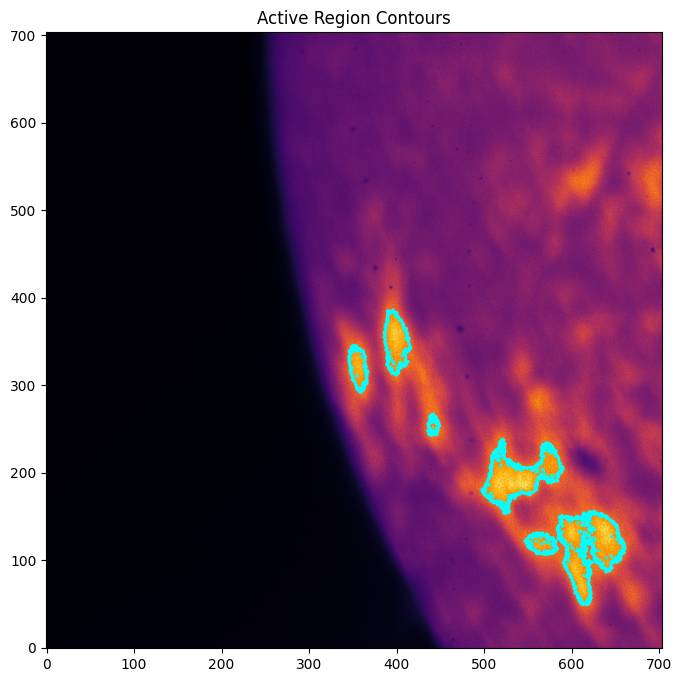

In [6]:
plt.figure(figsize=(8,8))

plt.imshow(
    normalized,
    origin="lower",
    cmap="inferno"
)

plt.contour(
    mask,
    colors="cyan",
    linewidths=2
)

plt.title("Active Region Contours")

plt.show()

## Comparative Analysis of Detected Active Regions

The number of active regions detected varies across different SUIT filters. This comparison highlights how different ultraviolet wavelengths emphasize different solar structures.

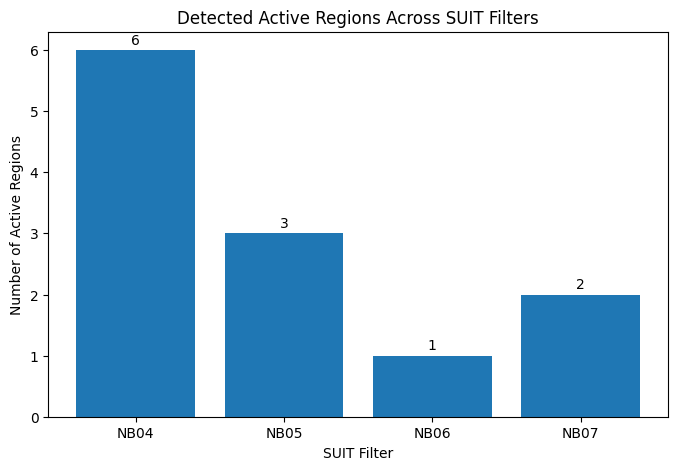

In [7]:
import matplotlib.pyplot as plt

filters = ["NB04", "NB05", "NB06", "NB07"]
regions = [6, 3, 1, 2]

plt.figure(figsize=(8,5))
plt.bar(filters, regions)

plt.xlabel("SUIT Filter")
plt.ylabel("Number of Active Regions")
plt.title("Detected Active Regions Across SUIT Filters")

for i, value in enumerate(regions):
    plt.text(i, value + 0.1, str(value), ha="center")

plt.savefig("active_region_counts.png", dpi=300, bbox_inches="tight")

plt.show()

## Results

The active region detection pipeline was applied to four SUIT ultraviolet filters. The number of detected active regions varied depending on the filter wavelength.

| Filter | Detected Active Regions |
|----------|----------|
| NB04 | 6 |
| NB05 | 3 |
| NB06 | 1 |
| NB07 | 2 |

## Validation with NOAA Solar Region Summary

Validation was performed using NOAA Solar Region Summary (SRS) data for 07 January 2024.

NOAA reported the following active regions:

- AR3536
- AR3539
- AR3540

Total NOAA Active Regions: 3

The NB05 filter detected three active regions, showing the closest agreement with NOAA observations. Other filters highlighted additional ultraviolet structures, resulting in different region counts.

## Limitations

- A fixed threshold value of 0.7 was used for segmentation.
- Faint active regions may not be detected.
- Different SUIT filters emphasize different solar atmospheric layers.
- Some bright structures may be split into multiple detections.
- Only four observations from a single date were analyzed.

## Conclusion

Solar active regions were successfully detected from Aditya-L1 SUIT ultraviolet imagery using threshold-based image processing techniques. Image normalization, morphological filtering, connected-component labeling, and contour visualization were used to identify active regions. Validation using NOAA Solar Region Summary data showed reasonable agreement with external observations, with the NB05 filter providing the closest match to NOAA reported active regions.